# Shallow CNN training
This notebook trains a small (shallow) convolutional neural network on an image classification dataset organized for `torchvision.datasets.ImageFolder`.

Before running: set `path2Train` and `path2Test` in the first code cell to point to your folders (they should contain class subfolders like `glioma`, `meningioma`, `notumor`, `pituitary`).

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

c:\Users\Rate\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Rate\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\1


In [2]:
# Configuration - set these paths before running
path2Train = "C:\\Users\\Rate\\.cache\\kagglehub\\datasets\\masoudnickparvar\\brain-tumor-mri-dataset\\versions\\1\\Training"  # e.g. 'data/train'
path2Test = "C:\\Users\\Rate\\.cache\\kagglehub\\datasets\\masoudnickparvar\\brain-tumor-mri-dataset\\versions\\1\\Testing"    # e.g. 'data/test'
batch_size = 32
num_epochs = 30
learning_rate = 1e-3
image_size = (224, 224)

In [3]:
# Imports and dataset/dataloader setup
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
import os
import sys
from pathlib import Path
repo_root = Path.cwd().resolve()
markers = ('utils', 'requirements.txt', 'README.md', '.git')
found = False
while True:
    for m in markers:
        if (repo_root / m).exists():
            found = True
            break
    if found or repo_root.parent == repo_root:
        break
    repo_root = repo_root.parent
if not found:
    print(f'Warning: project root markers not found; using {repo_root} (may not contain utils)')
else:
    print(f'Project root detected: {repo_root}')
sys.path.insert(0, str(repo_root))
print('sys.path[0] =', sys.path[0])
try:
    from utils.denormalize_img import show_image
except Exception as e:
    print('Failed to import utils.denormalize_img via package import:', e)
    fallback_path = repo_root / 'utils' / 'denormalize_img.py'
    if fallback_path.exists():
        import importlib.util
        spec = importlib.util.spec_from_file_location('utils.denormalize_img', str(fallback_path))
        module = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(module)
        show_image = module.show_image
        print(f'Loaded show_image from {fallback_path} via importlib')
    else:
        print('Fallback file not found at', fallback_path)
        raise

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

if not os.path.exists(path2Train) or not os.path.exists(path2Test):
    print("Warning: training or testing path does not exist. Update `path2Train` and `path2Test` before running.")

train_data = datasets.ImageFolder(root=path2Train, transform=transform)
test_data = datasets.ImageFolder(root=path2Test, transform=transform)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0)

print('Classes:', train_data.classes)
num_classes = len(train_data.classes)
print('Num training images:', len(train_data))
print('Num testing images:', len(test_data))

Project root detected: C:\Users\Rate\Documents\GitHub\CS6140FinalProject_Liu_Zhu_Kyvaag
sys.path[0] = C:\Users\Rate\Documents\GitHub\CS6140FinalProject_Liu_Zhu_Kyvaag
Device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Num training images: 5712
Num testing images: 1311


Conv2d(3 → 16, kernel=5, pad=2) → ReLU → MaxPool2d(2) → Conv2d(16 → 32, kernel=5, pad=2) → ReLU → MaxPool2d(2)
Flatten() → Linear(32 * (image_size[0]//4) * (image_size[1]//4) → 128) → ReLU → Dropout(0.5) → Linear(128 → num_classes)
32 * 56 * 56 = 100352

In [4]:
# Define a shallow CNN
class ShallowCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * (image_size[0]//4) * (image_size[1]//4), 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = ShallowCNN(num_classes=num_classes).to(device)
print(model)

ShallowCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [5]:
# Training utilities
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [6]:
# Run training
best_val_acc = 0.0
for epoch in range(1, num_epochs+1):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)
    elapsed = time.time() - start
    print(f'Epoch {epoch}/{num_epochs} - {elapsed:.1f}s - train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}')
    # simple checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'shallow_nn_best.pth')

print('Training finished. Best val acc:', best_val_acc)

Epoch 1/30 - 27.3s - train_loss: 0.6943 train_acc: 0.7432 val_loss: 0.4527 val_acc: 0.8307
Epoch 2/30 - 25.9s - train_loss: 0.3347 train_acc: 0.8761 val_loss: 0.2512 val_acc: 0.9092
Epoch 3/30 - 25.3s - train_loss: 0.2190 train_acc: 0.9189 val_loss: 0.1979 val_acc: 0.9298
Epoch 4/30 - 29.1s - train_loss: 0.1290 train_acc: 0.9527 val_loss: 0.1802 val_acc: 0.9390
Epoch 5/30 - 30.0s - train_loss: 0.0943 train_acc: 0.9683 val_loss: 0.1365 val_acc: 0.9542
Epoch 6/30 - 29.4s - train_loss: 0.0709 train_acc: 0.9758 val_loss: 0.1242 val_acc: 0.9611
Epoch 7/30 - 29.0s - train_loss: 0.0525 train_acc: 0.9825 val_loss: 0.1347 val_acc: 0.9626
Epoch 8/30 - 29.5s - train_loss: 0.0443 train_acc: 0.9841 val_loss: 0.1452 val_acc: 0.9626
Epoch 9/30 - 28.8s - train_loss: 0.0420 train_acc: 0.9844 val_loss: 0.2364 val_acc: 0.9336
Epoch 10/30 - 28.7s - train_loss: 0.0422 train_acc: 0.9860 val_loss: 0.1881 val_acc: 0.9550
Epoch 11/30 - 28.4s - train_loss: 0.0295 train_acc: 0.9907 val_loss: 0.1614 val_acc: 0.95

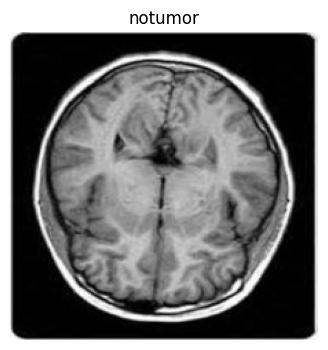

In [7]:
# Quick visualization example - show one sample with label
try:
    img, lbl = test_data[1000]
    show_image(img, lbl, classes=test_data.classes)
except Exception as e:
    print('Could not show example image:', e)